# MNIST Classification With Kmeans

## Introduction

This project implements the K-means algorithm from scratch to cluster the MNIST handwritten digit dataset. The objective is to find clusterings that align as closely as possible with the underlying digit classes, while using only distance-based similarity in pixel space. More broadly, the project investigates what this simple approach is able to capture, and where it falls short when applied to high-dimensional image data.

Each image is represented as a 28 × 28 grid of pixel values, where larger values correspond to darker regions of the digit and smaller values correspond to the background. As part of preprocessing, these grids are flattened into 784-dimensional vectors, allowing distances between images to be computed directly.

## Function Implementation Highlights

Cluster assignment is performed using fully vectorized distance computations. Instead of looping over data points and centroids, squared Euclidean distances are computed simultaneously across all pairs, allowing for efficient reassignment even in high-dimensional space.

```python
    distances = np.sum((XData[:, None, :] - c[None, :, :]) ** 2, axis=2)
    IndexSet = np.argmin(distances, axis=1)
```

Centroids are updated using the standard K-means update rule, taking the mean of all points assigned to each cluster. Empty clusters are handled explicitly by leaving their centroids unchanged, preventing instability during updates.

Centroid initialization is performed using the K-means++ method, which selects new centroids with probability proportional to their squared distance from existing centroids. This encourages initial centroids to be well-separated and improves both convergence speed and final cluster quality.

```python
    probabilities = distances / np.sum(distances)
    next_index = np.random.choice(n, p=probabilities)
```

To reduce sensitivity to initialization, the algorithm is run multiple times with different starting configurations. The final clustering is selected based on the lowest total within-cluster sum of squares (coherence), ensuring that results reflect a strong local optimum rather than a poor random initialization.

Convergence is determined by checking for stability in centroid positions using a numerical tolerance (np.allclose), with a maximum iteration cap to prevent infinite loops in degenerate cases.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from collections import Counter
import random

np.random.seed(0)

#data pulled from matlab file
XData = np.array([[0.676542075262776, 0.591754923810860],
                  [0.581191066718446, 0.665247067210415],
                  [0.805778446078608, 0.621489693069540],
                  [0.794418878358550, 0.753513275439461],
                  [0.564950715605087, 0.792839666955880],
                  [0.833875694768444, 0.704800720479260],
                  [0.807310277722215, 0.596512886789552],
                  [0.785041822541303, 0.834827635388373],
                  [0.806919053507215, 0.634927129442308],
                  [0.621013311395175, 0.713801215691695],
                  [-0.737899650939035, 0.700839715952625],
                  [-0.558935689312983, 0.738450318520371],
                  [-0.573634187288365, 0.704239445728095],
                  [-0.725722813254867, 0.788903452903205],
                  [-0.633886810997047, 0.689978001439847],
                  [-0.841206765433534, 0.583453334433772],
                  [-0.617710993883262, 0.753781493074906],
                  [-0.847406115152622, 0.724226830090905],
                  [-0.641166314718890, 0.590229195873635],
                  [-0.792112568302464, 0.800412845871485],
                  [0.598705346047328, -0.592537020966620],
                  [0.834173599693639, -0.853280112335705],
                  [0.670254557099446, -0.806763274493268],
                  [0.719173619910005, -0.826608050708199],
                  [0.568887104953471, -0.577138047654484],
                  [0.848584346045813, -0.748828375172271],
                  [0.750368402316571, -0.836722590558443],
                  [0.619480380111237, -0.845225627153827],
                  [0.697914575153703, -0.812077764387758],
                  [0.854498857541805, -0.728988076858639],
                  [-0.570495150295241, -0.639832671130522],
                  [-0.682839267477415, -0.695029408960313],
                  [-0.645474423717323, -0.855598116196211],
                  [-0.622352047535675, -0.579048909170895],
                  [-0.854618083968756, -0.609718278386629],
                  [-0.626906020778184, -0.557965712581942],
                  [-0.788810859569082, -0.581244119328208],
                  [-0.664506989530013, -0.825510726293773],
                  [-0.776658507073043, -0.627953651824672],
                  [-0.615453734513885, -0.825830881905972],
                  [0.290927632887853, 0.869657768684298],
                  [0.426812371962817, 0.900035991021790],
                  [0.407263142634234, 0.881893201713482],
                  [0.413418882811985, 0.860419486465715],
                  [0.377758151204946, 0.813445991450608],
                  [0.342701747124889, 0.974000475245139],
                  [0.262922863635020, 0.867703715248906],
                  [0.387647051859777, 0.847572245454329],
                  [0.296742735117197, 0.807792925479074],
                  [0.205983607443659, 0.949508338501877]])


In [44]:
def updateCentroids(k, XData, IndexSet, m):
    # Moves the Centroids to the mean value of points in a cluster
    # Parameters:
    # k - The number of clusters
    # XData - Data
    # IndexSet - List which includes the cluster assignment of each point of the XData.
    #           ie: If row five of the XData array is currently in the 4th cluster,
    #           then the fifth value of IndexSet will be 4.
    # m - dimension of XData, ie: number of values in each vector.
    # Returns c, an updated array of the centroids for each cluster.
    c = np.zeros((k, m))
    for i in range(k):
        cluster_points = XData[IndexSet == i]
        if len(cluster_points) > 0:
            c[i] = np.mean(cluster_points, axis=0)
    return c


def reassignVectors(k, XData, c):
    # Reassigns data vectors to the cluster associated with the closest centroid.
    # Parameters:
    # k - The number of clusters
    # XData - Data
    # c - An array containing each centroid (1 per cluster)
    # Returns IndexSet, a list which includes the cluster assignment of each point of the XData.

    # n = XData.shape[0]  # Get number of data points
    # IndexSet = np.zeros(n, dtype=int)  # Initialize the closest cluster array

    # # Loop over each data point
    # for d in range(n):
    #     xD = XData[d, :]  # Get the current data point

    #     # Set the initial minimum distance to a very large number
    #     sq_dist_min = 1e16

    #     # Loop over each cluster centroid to find the closest one
    #     for i in range(k):
    #         # Compute the Euclidean distance between the data point and the current cluster centroid
    #         sq_dist = np.linalg.norm(c[i, :] - xD)

    #         # If the current centroid is closer than the previous minimum, update the closest cluster
    #         if sq_dist < sq_dist_min:
    #             IndexSet[d] = i
    #             sq_dist_min = sq_dist

    # return IndexSet

    distances = np.sum((XData[:, None, :] - c[None, :, :]) ** 2, axis=2)
    return np.argmin(distances, axis=1)


def makeClusterPlot(k, XData, c, IndexSet):
    # Plots the centroids, clusters, and data points
    # Parameters:
    # k - The number of clusters
    # XData - Data
    # c - An array containing each centroid (1 per cluster)
    # IndexSet - a list which includes the cluster assignment of each point of the XData.

    plt.figure()
    for i in range(k):
        cluster_points = XData[IndexSet == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i + 1}')
    plt.scatter(c[:, 0], c[:, 1], color='red', marker='x', s=100, label='Centroids')
    plt.legend()


def kMeans(XData, k, kpp, plotall, init=None, restarts=1):
    # Performs k-means clustering, optionally with multiple restarts.
    # Returns the best result by lowest coherence.

    m = XData.shape[1]
    n = XData.shape[0]

    best_Q = float("inf")
    best_c = None
    best_IndexSet = None

    for restart in range(restarts):

        c = np.zeros((k, m))
        cPrev = np.zeros((k, m))

        if kpp == True and k > 1:
            if init is None:
                c[0] = XData[np.random.randint(0, n)]
            else:
                c[0] = XData[init - 1]

            for i in range(1, k):
                # compute squared distance to nearest existing centroid
                distances = np.min(
                    np.sum((XData[:, None, :] - c[None, :i, :]) ** 2, axis=2),
                    axis=1
                )

                # safety check goes HERE
                if np.sum(distances) == 0:
                    next_index = np.random.randint(0, n)
                else:
                    probabilities = distances / np.sum(distances)
                    next_index = np.random.choice(n, p=probabilities)

                c[i] = XData[next_index]

            IndexSet = reassignVectors(k, XData, c)

        else:
            # Randomly initialize centroids from existing data points
            random_indices = np.random.choice(n, size=k, replace=False)
            c = XData[random_indices]

            IndexSet = reassignVectors(k, XData, c)

        doneFlag = False
        max_iter = 100
        iter_count = 0

        while not doneFlag and iter_count < max_iter:
            c = updateCentroids(k, XData, IndexSet, m)

            if plotall == 0 and restarts == 1:
                makeClusterPlot(k, XData, c, IndexSet)

            IndexSet = reassignVectors(k, XData, c)

            if plotall == 0 and restarts == 1:
                makeClusterPlot(k, XData, c, IndexSet)

            if np.allclose(c, cPrev):
                doneFlag = True
            else:
                cPrev = np.copy(c)

            iter_count += 1

        Q = compute_coherence(XData, c, IndexSet)

        if Q < best_Q:
            best_Q = Q
            best_c = np.copy(c)
            best_IndexSet = np.copy(IndexSet)

    if plotall == 1:
        makeClusterPlot(k, XData, best_c, best_IndexSet)

    return (best_c, best_IndexSet)

def compute_coherence(XData, c, IndexSet):
    Q = 0
    for i in range(len(c)):
        cluster_points = XData[IndexSet == i]
        Q += np.sum((cluster_points - c[i]) ** 2)
    return Q

def elbowMethod(XData, minSize, maxSize, kpp, init=None, runs=1, restarts = 1):
    # Performs the elbow method on a set of XData to determine ideal cluster size
    # Parameters:
    # XData - Data
    # minSize - Smallest cluster size tested
    # maxSize - Largest cluster siz tested
    # kpp - Boolean, perform kpp initialization if true
    # Returns an array containing the coherence for each cluster size, plots the coherence.
    # init - Allows you to choose a starting representative vector for kpp clustering, can be 
    #        left blank if you want to use a random starting vector.
    # runs - Number of times performing the elbow method, will plot all curves on the same graph

    # simplifies using range function, lazy programming
    plt.figure()
    plt.xlabel('Number of clusters')
    plt.ylabel('Total coherence')

    plt.title('Elbow Method Plot')
    for z in range(runs):

        # Empty array to store total coherences
        Q_array = np.zeros((maxSize + 1) - minSize)

        # loops through the different possible cluster sizes
        for k in range(minSize, (maxSize + 1)):

            # Variable to store the kmeans result
            clustered = kMeans(XData, k, kpp=kpp, plotall=2, init=init, restarts = restarts)

            # Final centroids
            c = clustered[0]

            # Final indices
            IndexSet = clustered[1]

            # initializes total coherence
            Q = 0

            # loops through the cluster. This way you can calculate the coherence for each cluster.
            for i in range(k):
                cluster_points = XData[IndexSet == i]

                # initializes cluster coherence
                ql = 0

                # loops through the points in a cluster and calculates coherence
                for l in range(len(cluster_points)):
                    ql += np.linalg.norm(c[i, :] - cluster_points[l]) ** 2

                Q += ql
            Q_array[k - minSize] = Q

        plt.scatter(range(minSize, maxSize + 1), Q_array)
        plt.plot(range(minSize, maxSize + 1), Q_array, label=f'Coherence {z + 1}')

    plt.legend()


    return Q_array

def print_clusters(cluster_list, XData, IndexSet, title, max_images=10):
    n_clusters = len(cluster_list)
    n_cols = max_images  # 15 columns
    n_rows = n_clusters  # 1 row per cluster

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 1.8 * n_clusters))

    if n_clusters == 1:
        axes = np.array([axes])

    for i, cluster_num in enumerate(cluster_list):
        cluster_points = XData[IndexSet == cluster_num - 1]
        num_images = min(len(cluster_points), max_images)

        for j in range(n_cols):
            ax = axes[i, j]
            ax.axis("off")

            if j < num_images:
                ax.imshow(cluster_points[j], cmap="gray", vmin=0, vmax=1)

        # label row
        axes[i, 0].text(
            -0.3, 0.5,
            f"Cluster {cluster_num}",
            transform=axes[i, 0].transAxes,
            fontsize=12,
            va='center',
            rotation = 90
        )
    plt.subplots_adjust(hspace=0.1)
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()

        
def compute_success_score(mnistKMeans, y_labels, k):
    cluster_assignments = mnistKMeans[1]
    cluster_labels = {}

    for cluster in range(k):
        cluster_indices = np.where(cluster_assignments == cluster)[0]
        cluster_true_labels = y_labels[cluster_indices]

        if len(cluster_true_labels) == 0:
            continue

        label_counts = Counter(cluster_true_labels)
        representative_label = label_counts.most_common(1)[0][0]
        cluster_labels[cluster] = representative_label

    correct_count = sum(
        1 for i in range(len(y_labels))
        if cluster_assignments[i] in cluster_labels
        and y_labels[i] == cluster_labels[cluster_assignments[i]]
    )

    return (correct_count / len(y_labels)) * 100

def cluster_purity(mnistKMeans, y_labels, k):
    cluster_assignments = mnistKMeans[1]
    purity = []

    for cluster in range(k):
        indices = np.where(cluster_assignments == cluster)[0]
        labels = y_labels[indices]

        if len(labels) == 0:
            purity.append(0)
            continue

        counts = Counter(labels)
        max_count = counts.most_common(1)[0][1]
        purity.append(max_count / len(labels))

    return purity

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data(path="mnist.npz")

#selects the first 500 from the training data
X_train500 = x_train[:500]
y_train500 = y_train[:500]

initial_centroids_dict = {}

#converts to [0...1] scale
X_train500 = X_train500.astype("float32") / 255

# Reshape the images into vectors (flatten each 28x28 image into a 784-length vector)
X_train500_flattened = X_train500.reshape(X_train500.shape[0], -1)

## Finding the Best Number of Clusters

To determine an appropriate number of clusters in K-means, we use a diagnostic known as the elbow plot. This plot measures the total within-cluster coherence, defined as the sum of squared distances between each point and its assigned centroid. As the number of clusters increases, this value decreases, since points are grouped more tightly.

When inspecting the elbow plot, we look for changes in the rate of decrease. An inflection point, or “elbow,” occurs where additional clusters yield only marginal reductions in coherence. This point is often taken as a reasonable balance between model complexity and cluster compactness.

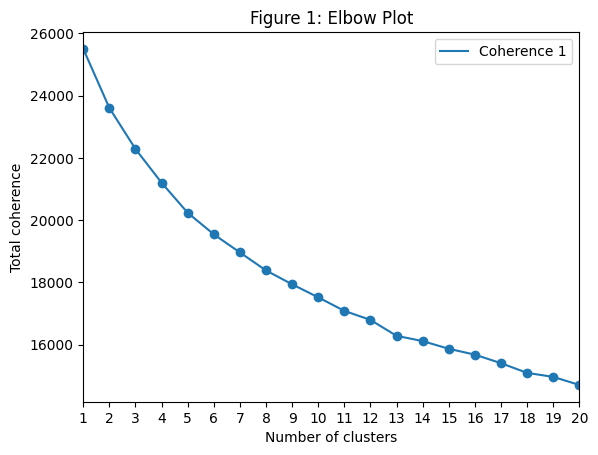

In [59]:
np.random.seed(0)
elbowMethod(X_train500_flattened, 1, 20, kpp=True, restarts = 20)
plt.title(label = "Figure 1: Elbow Plot")
plt.xticks(range(1,21))
plt.xlim(1, 20)
plt.show()

The elbow plot (Figure 1) does not exhibit a sharp transition, but instead shows a gradual reduction in coherence. A natural inflection point appears around k=10, corresponding roughly to the number of digit classes. However, further improvements in coherence are observed for larger values of k, with another potential elbow around k=16-17, suggesting that the algorithm captures finer stylistic variations within digits rather than distinct classes.

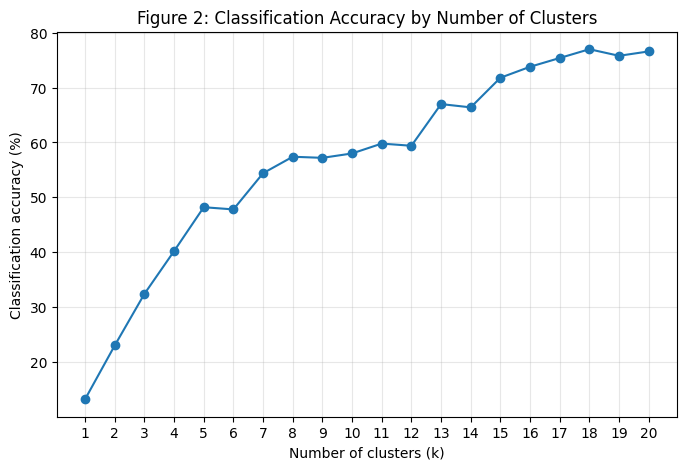

In [60]:
np.random.seed(0)
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    model = kMeans(
        X_train500_flattened,
        k,
        kpp=True,
        plotall=2,
        restarts=20
    )
    
    score = compute_success_score(model, y_train500, k)
    accuracy_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Classification accuracy (%)")
plt.title("Figure 2: Classification Accuracy by Number of Clusters")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

The pattern observed in the elbow plot is reflected in the classification accuracy plot. Here, accuracy is defined as the proportion of observations whose true digit label matches the majority label of their assigned cluster.

In Figure 2, accuracy increases with the number of clusters up to approximately k=9, after which it stabilizes before increasing again around k=13, eventually reaching a plateau near k=17. This behavior is consistent with the interpretation from the elbow plot: K-means tends to identify clusters corresponding roughly to the ten digit classes, but allowing for additional clusters improves label purity by capturing stylistic variation within digits.

To investigate this further, we examine the centroids for k=10 and k=17. The centroids represent the mean image of each cluster, formed by averaging all images assigned to that cluster. As a result, they provide a visual summary of the typical digit or style captured by each group.

## Investigating Cluster Contents

### With K = 10

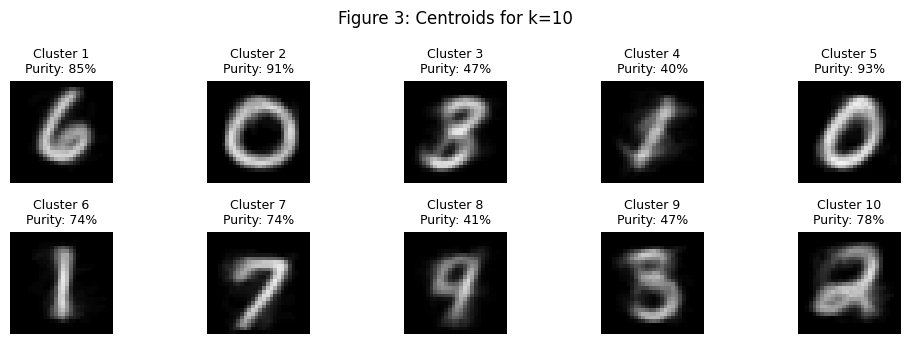

In [47]:
np.random.seed(0)
mnistKMeans_10 = kMeans(X_train500_flattened, 10, kpp=True, plotall=2, restarts = 20)
centroids = mnistKMeans_10[0].reshape(10, 28, 28)

purities = cluster_purity(mnistKMeans_10, y_train500, 10)

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(3, 5, i + 1)
    plt.imshow(centroids[i], cmap='gray', vmin=0, vmax=1)
    plt.title(f'Cluster {i+1}\nPurity: {purities[i]*100:.0f}%', fontsize=9)
    plt.axis('off')

plt.suptitle("Figure 3: Centroids for k=10")
plt.tight_layout()
plt.show()

When we plot the centroids for our ten-cluster classification (Figure 3), several patterns emerge. Some digits (0, 1, 2, 6, and 7) have well-defined, legible centroids, indicating that these clusters are relatively internally consistent. This is reflected in high purity scores, which measure how many images in the cluster match the majority label. 

The algorithm has created two clusters of zeros, one more centered and one more tilted; here, the algorithm reflects geometric differences between writing styles. Other clusters are less distinct, with blurred or ambiguous centroids and low purity scores, suggesting that they contain a mixture of digits with similar visual features.

To better understand these groupings, we display example images from clusters 1, 3, 4, and 8.

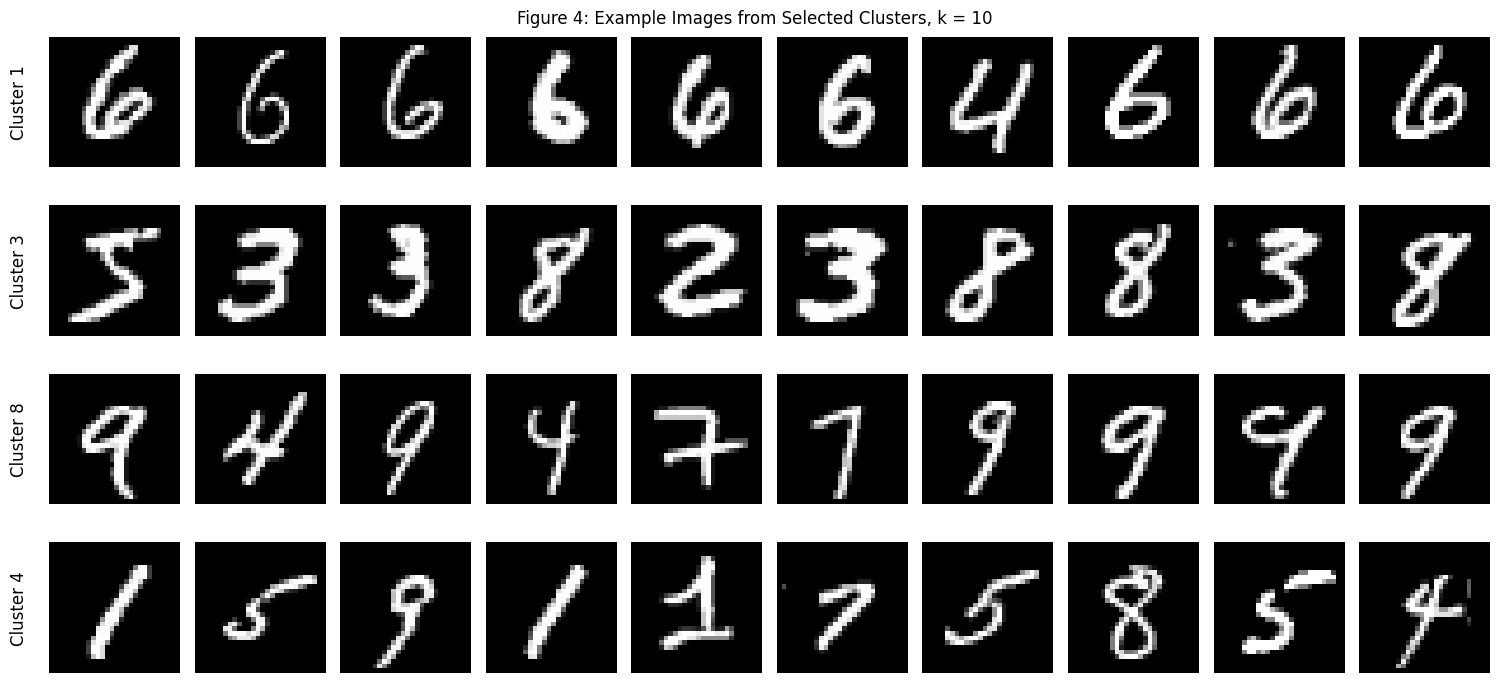

In [40]:
print_clusters([1, 3, 8, 4], X_train500, mnistKMeans_10[1], title = "Figure 4: Example Images from Selected Clusters, k = 10", max_images= 10)
plt.show()

Cluster 1 is an example of a well-defined, cohesive cluster, containing almost exclusively sixes. Like the clusters of zeroes in Figure 3, the digit 6 has a distinctive shape, allowing a geometry-based algorithm to classify it effectively.

In clusters 3 and 8, we see how K-means groups digits that are geometrically similar but semantically distinct. The threes and eights in cluster 3, and the fours and nines in cluster 8, share similar structural features and are therefore grouped together, despite representing different digits.

Cluster 4 illustrates a different type of behavior. Here, the digits are not especially similar in overall shape, but many exhibit a similar tilt or stroke orientation. In this case, K-means appears to be grouping observations based on writing style rather than digit form. This highlights a key limitation of the algorithm: because it relies solely on Euclidean distance in pixel space, it may capture superficial visual similarities that do not align with the underlying categories.

We can now compare these results with the centroids from the k=17 clustering, which may capture finer stylistic variations.

### With k = 17

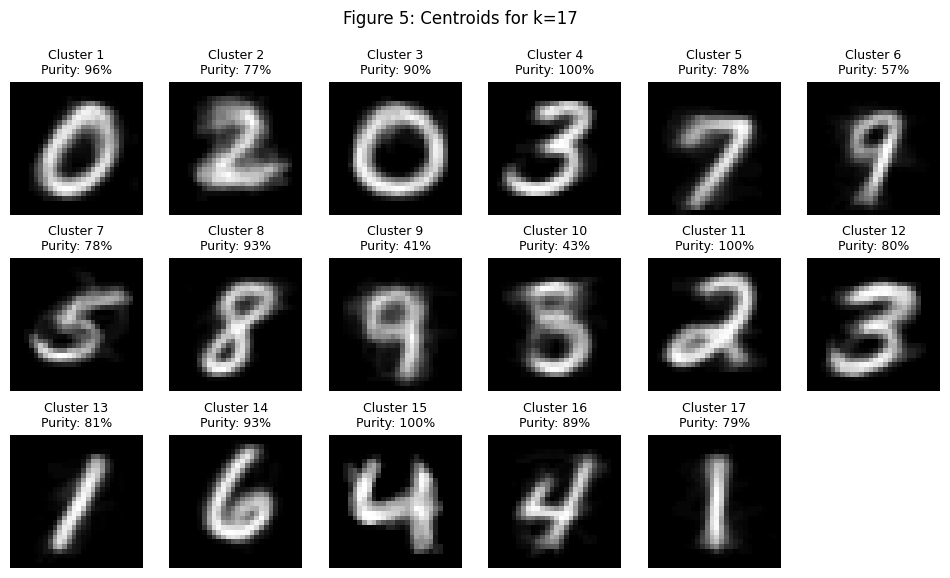

In [55]:
np.random.seed(0)
mnistKMeans_17 = kMeans(X_train500_flattened, 17, kpp=True, plotall=2, restarts = 20)
centroids = mnistKMeans_17[0].reshape(17, 28, 28)
purities = cluster_purity(mnistKMeans_17, y_train500, 17)

plt.figure(figsize=(12, 6.5))
for i in range(17):
    plt.subplot(3, 6, i + 1)  # Adjust subplot based on the value of k
    plt.imshow(centroids[i], cmap='gray')
    plt.title(f'Cluster {i+1}\nPurity: {purities[i]*100:.0f}%', fontsize=9)
    plt.axis('off')

plt.suptitle('Figure 5: Centroids for k=17')
plt.show()

Upon plotting centroids for the 17-cluster classification (Figure 5), we observe that most clusters produce well-defined, legible centroids with high purity scores. A few clusters, such as the groups of twos, threes, and fours in clusters 4, 11, and, 15, are 100% pure. Every digit, and several stylistic differences are represented. Clusters 13 and 17 represent two different styles of the digit 1, one more tilted and one more vertical. Clusters 2 and 11 distinguish between twos written with a straight and looped base. 

This reflects the effect of increasing k: rather than grouping all instances of a digit together, K-means begins to partition digits into subgroups based on writing style.

Still, some messy clusters persist, particularly clusters 9 and 10. We will again plot examples to better understand groupings.

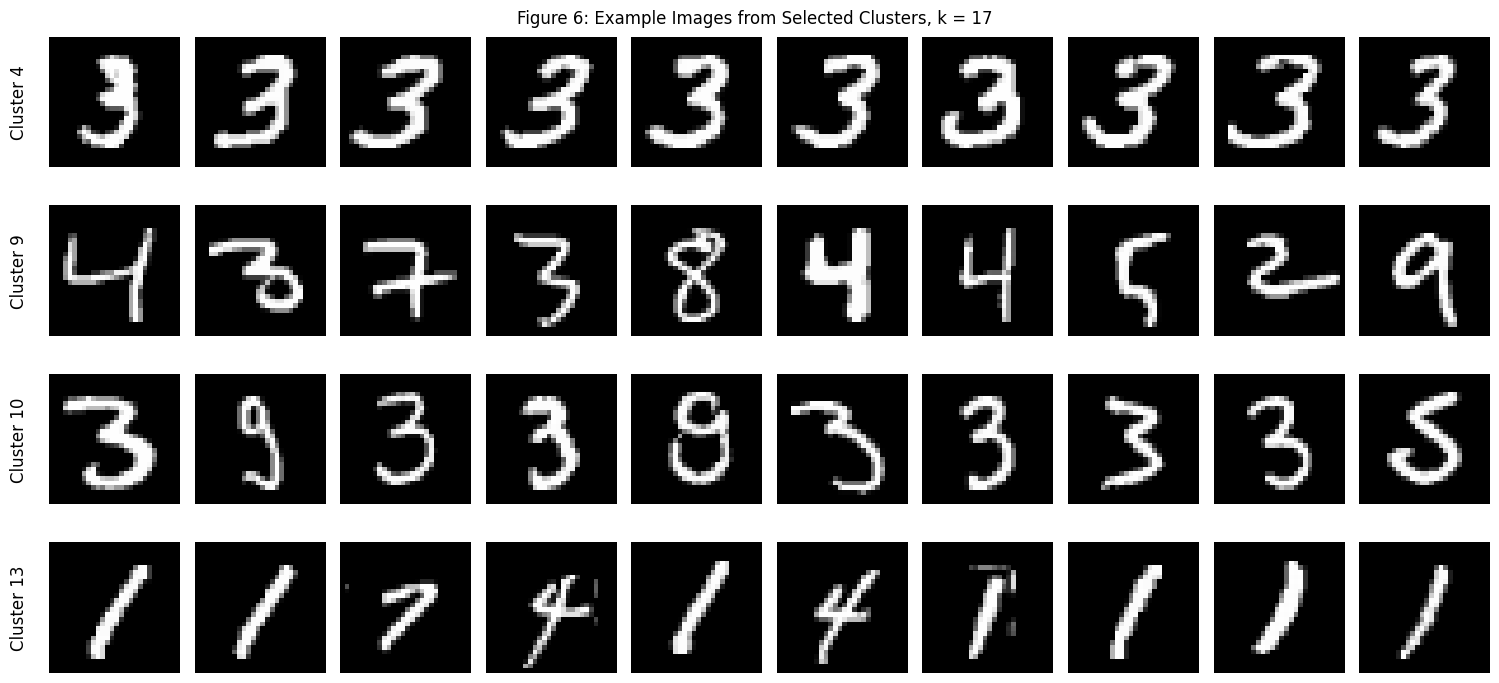

In [53]:
print_clusters([4, 9, 10, 13], X_train500, mnistKMeans_17[1], title = "Figure 6: Example Images from Selected Clusters, k = 17")
plt.show()

In Cluster 4, all sample digits are threes written in a consistent style. The curvature and stroke placement of this particular form of “3” are distinctive in pixel space, allowing K-means to isolate it cleanly and achieve a purity score of 100%. This is an example of clustering that aligns well with both visual similarity and digit identity. 

In contrast, Cluster 9 contains a mixture of digits (2, 3, 4, 5, 7, 8, 9) with no clear shared structure. Rather than capturing a coherent digit class or stylistic variant, this cluster appears to group together observations that are not strongly similar to any dominant centroid. This suggests that K-means, when forced to partition all points, may create “residual” clusters that lack meaningful interpretation.

Cluster 10 and 13 are similar to clusters 3 and 4 from Figure 4 (the k=10 clusters). In cluster 10, there is a mixture of threes, nines, and fives which all appear very structurally similar. Although increasing the number of clusters has allowed kmeans to capture finer variations, it does not eliminate missclasification of digits that share geometric similarity to centroid for another digit.

The examples from cluster 13 are all dominated by a diagonal line, whether they are a 1, 4, or 7. Here, the geometric similarity arising from stroke style still forms clusters of distinct digits.

Ultimately, we see that increasing the number of clusters has allowed for more accuracy and purer groups by capturing finer stylistic variations and separating more of the geometrically similar digits. However, because K-means relies on simple distance-based similarity, it cannot fully distinguish between digits that share similar geometric structure.

## Conclusion

This project demonstrates that K-means is capable of recovering meaningful structure in handwritten digit data, particularly for digits with distinctive geometric features. Increasing the number of clusters improves purity by capturing stylistic variation within digits, rather than simply refining class boundaries. However, because clustering is based entirely on pixel-level similarity, the algorithm struggles to distinguish between digits that share similar structure. As a result, K-means reveals both the strengths and limitations of distance-based methods in high-dimensional image data.

## Data and Code

- [Download processed MNIST subset (CSV)](mnist/mnist_first500_processed.csv.csv)  
- [View full analysis code (Jupyter Notebook)](mnist/kmeans.ipynb)  